# Modern Data Storage and Query Engines

## The Dataset: NYC Yellow Taxi Trips 2023

**1. Download all 2023 monthly files**

In [1]:
import urllib.request
import os

os.makedirs("../data/taxi", exist_ok=True)

base_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/"

for month in range(1, 13):
    filename = f"yellow_tripdata_2023-{month:02d}.parquet"
    dest = f"../data/taxi/{filename}"
    if not os.path.exists(dest):
        urllib.request.urlretrieve(base_url + filename, dest)
        print(f"Downloaded {filename}")
    else:
        print(f"Already exists: {filename}")

Already exists: yellow_tripdata_2023-01.parquet
Already exists: yellow_tripdata_2023-02.parquet
Downloaded yellow_tripdata_2023-03.parquet
Downloaded yellow_tripdata_2023-04.parquet
Downloaded yellow_tripdata_2023-05.parquet
Downloaded yellow_tripdata_2023-06.parquet
Downloaded yellow_tripdata_2023-07.parquet
Downloaded yellow_tripdata_2023-08.parquet
Downloaded yellow_tripdata_2023-09.parquet
Downloaded yellow_tripdata_2023-10.parquet
Downloaded yellow_tripdata_2023-11.parquet
Downloaded yellow_tripdata_2023-12.parquet


**2. Verify with a quick Pandas inspection**

In [2]:
import pandas as pd
import glob

files = sorted(glob.glob("../data/taxi/yellow_tripdata_2023-*.parquet"))
print(f"Files found: {len(files)}")

# Inspect one file
sample = pd.read_parquet(files[0])
print(sample.shape)     # (3066766, 19)
print(sample.dtypes)

Files found: 12
(3066766, 19)
VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
dtype: object


## CSV Limitations

### What CSV was designed for

In [3]:
import pandas as pd

# Write the January taxi data to CSV for comparison
jan = pd.read_parquet("../data/taxi/yellow_tripdata_2023-01.parquet")
jan.to_csv("../data/taxi/yellow_tripdata_2023-01.csv", index=False)

# Compare file sizes
import os

parquet_size = os.path.getsize(
    "../data/taxi/yellow_tripdata_2023-01.parquet"
)
csv_size = os.path.getsize(
    "../data/taxi/yellow_tripdata_2023-01.csv"
)

print(f"Parquet: {parquet_size / 1e6:.1f} MB")
print(f"CSV:     {csv_size / 1e6:.1f} MB")
print(f"CSV is {csv_size / parquet_size:.1f}× larger on disk")

Parquet: 47.7 MB
CSV:     325.0 MB
CSV is 6.8× larger on disk


### The read performance problem

In [6]:
import time
import pandas as pd

# Read speed: CSV vs Parquet
t0 = time.perf_counter()
df_csv = pd.read_csv("../data/taxi/yellow_tripdata_2023-01.csv", low_memory=False)
csv_time = time.perf_counter() - t0

t0 = time.perf_counter()
df_pq = pd.read_parquet("../data/taxi/yellow_tripdata_2023-01.parquet")
parquet_time = time.perf_counter() - t0

print(f"CSV read:     {csv_time:.2f}s")
print(f"Parquet read: {parquet_time:.2f}s")
print(f"Parquet is {csv_time / parquet_time:.1f}× faster to read")

CSV read:     9.42s
Parquet read: 0.33s
Parquet is 28.2× faster to read


### The type safety problem

In [8]:
import pandas as pd

# Demonstrate CSV type inference pitfalls
csv_path = "../data/taxi/yellow_tripdata_2023-01.csv"
df = pd.read_csv(csv_path, low_memory=False)

# store_and_fwd_flag is a string 'Y'/'N' — inferred as object
print(df["store_and_fwd_flag"].dtype)   # object

# passenger_count contains nulls — inferred as float64, not int
print(df["passenger_count"].dtype)      # float64

# Parquet stores the intended type exactly
df_pq = pd.read_parquet(
    "../data/taxi/yellow_tripdata_2023-01.parquet"
)
print(df_pq["tpep_pickup_datetime"].dtype)  # datetime64[us]
# CSV would require an explicit parse_dates argument to achieve this

object
float64
datetime64[us]


## Parquet and Columnar Storage

In [9]:
import pyarrow.parquet as pq

# Inspect Parquet file metadata
pf = pq.read_metadata("../data/taxi/yellow_tripdata_2023-01.parquet")

print(f"Row groups:  {pf.num_row_groups}")
print(f"Rows:        {pf.num_rows}")
print(f"Columns:     {pf.num_columns}")
print(f"Serialized size: {pf.serialized_size / 1e6:.1f} MB")

# Inspect statistics for the fare_amount column in row group 0
rg = pf.row_group(0)
col = rg.column(rg.num_columns - 3)   # fare_amount index varies; iterate to find
for i in range(rg.num_columns):
    c = rg.column(i)
    if c.path_in_schema == "fare_amount":
        stats = c.statistics
        print(f"\nfare_amount statistics:")
        print(f"  min:        {stats.min}")
        print(f"  max:        {stats.max}")
        print(f"  null_count: {stats.null_count}")
        print(f"  compressed: {c.total_compressed_size / 1e6:.2f} MB")
        print(f"  uncompressed: {c.total_uncompressed_size / 1e6:.2f} MB")

Row groups:  1
Rows:        3066766
Columns:     19
Serialized size: 0.0 MB

fare_amount statistics:
  min:        -900.0
  max:        1160.1
  null_count: 0
  compressed: 3.09 MB
  uncompressed: 4.53 MB


### Reading and writing Parquet with Pandas and Polars

In [10]:
import pandas as pd
import polars as pl

path = "../data/taxi/yellow_tripdata_2023-01.parquet"

# --- Pandas ---
# Read all columns
df_pd = pd.read_parquet(path)

# Read only selected columns — much faster for wide tables
df_pd_cols = pd.read_parquet(
    path,
    columns=["tpep_pickup_datetime", "trip_distance",
             "fare_amount", "tip_amount", "payment_type"]
)
print(df_pd_cols.shape)    # (3066766, 5)

# Write back to Parquet with Snappy compression (default)
df_pd_cols.to_parquet(
    "../data/taxi/jan_subset.parquet",
    index=False,
    compression="snappy"
)

# --- Polars ---
df_pl = pl.read_parquet(path)

# Projection pushdown: Polars reads only the requested columns from disk
df_pl_cols = pl.read_parquet(
    path,
    columns=["tpep_pickup_datetime", "trip_distance",
             "fare_amount", "tip_amount", "payment_type"]
)
print(df_pl_cols.shape)    # (3066766, 5)

# Write to Parquet
df_pl_cols.write_parquet(
    "../data/taxi/jan_subset_polars.parquet",
    compression="snappy"
)

(3066766, 5)
(3066766, 5)


### Parquet compression codecs

In [11]:
import pandas as pd
import os
import time

df = pd.read_parquet("../data/taxi/yellow_tripdata_2023-01.parquet")

for codec in ["snappy", "gzip", "zstd", "none"]:
    out = f"../data/taxi/jan_{codec}.parquet"
    t0 = time.perf_counter()
    df.to_parquet(out, compression=codec if codec != "none" else None,
                  index=False)
    write_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    _ = pd.read_parquet(out)
    read_time = time.perf_counter() - t0

    size_mb = os.path.getsize(out) / 1e6
    print(f"{codec:8s}  size={size_mb:6.1f} MB  "
          f"write={write_time:.2f}s  read={read_time:.2f}s")

snappy    size=  62.8 MB  write=5.06s  read=0.30s
gzip      size=  48.1 MB  write=38.25s  read=0.36s
zstd      size=  50.7 MB  write=4.76s  read=0.33s
none      size=  80.5 MB  write=5.05s  read=0.30s


### Column-selective reads and predicate pushdown

In [12]:
import pandas as pd
import time

path = "../data/taxi/yellow_tripdata_2023-01.parquet"

# Benchmark 1: read all 19 columns
t0 = time.perf_counter()
df_all = pd.read_parquet(path)
print(f"All columns ({len(df_all.columns)}):  "
      f"{time.perf_counter() - t0:.2f}s  "
      f"{df_all.memory_usage(deep=True).sum() / 1e6:.0f} MB in memory")

# Benchmark 2: read only 3 columns
t0 = time.perf_counter()
df_few = pd.read_parquet(
    path, columns=["fare_amount", "tip_amount", "payment_type"]
)
print(f"3 columns:               "
      f"{time.perf_counter() - t0:.2f}s  "
      f"{df_few.memory_usage(deep=True).sum() / 1e6:.0f} MB in memory")

All columns (19):  0.40s  593 MB in memory
3 columns:               0.08s  74 MB in memory


## Apache Arrow

### Working with PyArrow directly

In [14]:
import pyarrow as pa
import pyarrow.parquet as pq
import pandas as pd
import polars as pl

# Read a Parquet file into an Arrow Table
table = pq.read_table(
    "../data/taxi/yellow_tripdata_2023-01.parquet",
    columns=["trip_distance", "fare_amount", "tip_amount",
             "payment_type", "tpep_pickup_datetime"]
)

print(type(table))           # <class 'pyarrow.lib.Table'>
print(table.schema)
print(f"Rows: {table.num_rows:,}")
print(f"Columns: {table.num_columns}")

<class 'pyarrow.lib.Table'>
trip_distance: double
fare_amount: double
tip_amount: double
payment_type: int64
tpep_pickup_datetime: timestamp[us]
-- schema metadata --
pandas: '{"index_columns": [], "column_indexes": [], "columns": [{"name":' + 2492
Rows: 3,066,766
Columns: 5


### Zero-copy conversion between libraries

In [15]:
import pyarrow as pa
import pyarrow.parquet as pq
import pandas as pd
import polars as pl
import time

table = pq.read_table(
    "../data/taxi/yellow_tripdata_2023-01.parquet",
    columns=["trip_distance", "fare_amount", "tip_amount", "payment_type"]
)

# Arrow → Pandas (zero-copy where possible)
t0 = time.perf_counter()
df_pd = table.to_pandas()
print(f"Arrow → Pandas:  {time.perf_counter() - t0:.4f}s")

# Pandas → Arrow
t0 = time.perf_counter()
table2 = pa.Table.from_pandas(df_pd)
print(f"Pandas → Arrow:  {time.perf_counter() - t0:.4f}s")

# Arrow → Polars (zero-copy)
t0 = time.perf_counter()
df_pl = pl.from_arrow(table)
print(f"Arrow → Polars:  {time.perf_counter() - t0:.4f}s")

# Polars → Arrow
t0 = time.perf_counter()
table3 = df_pl.to_arrow()
print(f"Polars → Arrow:  {time.perf_counter() - t0:.4f}s")

Arrow → Pandas:  0.0765s
Pandas → Arrow:  0.2496s
Arrow → Polars:  0.2797s
Polars → Arrow:  0.0490s


### Building Arrow arrays and tables directly

In [16]:
import pyarrow as pa

# Construct a small Arrow Table from Python lists
fare_amounts  = pa.array([5.0, 12.5, 32.5, 7.0, 19.0], type=pa.float64())
trip_distances = pa.array([1.0,  3.5,  8.3, 1.5,  4.2], type=pa.float64())
payment_types  = pa.array([1, 2, 1, 1, 2],               type=pa.int32())

table = pa.table({
    "fare_amount":   fare_amounts,
    "trip_distance": trip_distances,
    "payment_type":  payment_types,
})

print(table)
print(table.schema)

pyarrow.Table
fare_amount: double
trip_distance: double
payment_type: int32
----
fare_amount: [[5,12.5,32.5,7,19]]
trip_distance: [[1,3.5,8.3,1.5,4.2]]
payment_type: [[1,2,1,1,2]]
fare_amount: double
trip_distance: double
payment_type: int32


## Partitioned Data

### Writing a partitioned Parquet dataset

In [17]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import glob
import os

output_dir = "../data/taxi/partitioned"
os.makedirs(output_dir, exist_ok=True)

# Read all 12 months and write as a partitioned dataset
files = sorted(glob.glob("../data/taxi/yellow_tripdata_2023-*.parquet"))

for month_num, filepath in enumerate(files, start=1):
    df = pd.read_parquet(
        filepath,
        columns=["tpep_pickup_datetime", "trip_distance",
                 "fare_amount", "tip_amount", "total_amount",
                 "payment_type", "PULocationID", "DOLocationID"]
    )

    # Filter out data quality issues
    df = df[
        (df["trip_distance"] > 0) &
        (df["fare_amount"] > 0) &
        (df["total_amount"] > 0)
    ].copy()

    # Add partition columns
    df["year"]  = 2023
    df["month"] = month_num

    table = pa.Table.from_pandas(df, preserve_index=False)

    pq.write_to_dataset(
        table,
        root_path=output_dir,
        partition_cols=["year", "month"],
        compression="snappy",
        existing_data_behavior="overwrite_or_ignore",
    )
    print(f"  Written month {month_num:02d}  ({len(df):,} rows)")

print(f"\nPartitioned dataset written to {output_dir}")

  Written month 01  (2,998,382 rows)
  Written month 02  (2,850,637 rows)
  Written month 03  (3,328,605 rows)
  Written month 04  (3,220,744 rows)
  Written month 05  (3,437,729 rows)
  Written month 06  (3,231,205 rows)
  Written month 07  (2,828,896 rows)
  Written month 08  (2,737,975 rows)
  Written month 09  (2,721,074 rows)
  Written month 10  (3,366,626 rows)
  Written month 11  (3,203,333 rows)
  Written month 12  (3,263,816 rows)

Partitioned dataset written to ../data/taxi/partitioned


### Reading a partitioned dataset

In [18]:
import pyarrow.parquet as pq
import polars as pl
import time

dataset_path = "../data/taxi/partitioned"

# --- PyArrow with partition filter ---
t0 = time.perf_counter()
table_q1 = pq.read_table(
    dataset_path,
    filters=[("month", "in", [1, 2, 3])],
    columns=["fare_amount", "trip_distance", "month"]
)
print(f"PyArrow Q1 read:  {time.perf_counter() - t0:.2f}s  "
      f"{table_q1.num_rows:,} rows")

# --- Polars lazy scan with partition filter ---
t0 = time.perf_counter()
df_q1 = (
    pl.scan_parquet(f"{dataset_path}/**/*.parquet",
                    hive_partitioning=True)
    .filter(pl.col("month").is_in([1, 2, 3]))
    .select(["fare_amount", "trip_distance", "month"])
    .collect()
)
print(f"Polars Q1 scan:   {time.perf_counter() - t0:.2f}s  "
      f"{len(df_q1):,} rows")

# --- Without filter: must read all 12 months ---
t0 = time.perf_counter()
table_all = pq.read_table(
    dataset_path,
    columns=["fare_amount", "trip_distance", "month"]
)
print(f"PyArrow all months: {time.perf_counter() - t0:.2f}s  "
      f"{table_all.num_rows:,} rows")

PyArrow Q1 read:  0.56s  9,177,624 rows
Polars Q1 scan:   1.16s  9,177,624 rows
PyArrow all months: 0.43s  37,189,022 rows


### Verifying partition pruning

In [24]:
import pyarrow.dataset as ds

# Load the dataset with explicit Hive-style partitioning
dataset = ds.dataset(
    "../data/taxi/partitioned",
    format="parquet",
    partitioning="hive"   # Important: matches year=2023/month=6 directory structure
)

# Get only the fragments that survive partition pruning
fragments = list(dataset.get_fragments(filter=ds.field("month") == 6))

print(f"Files selected after pruning: {len(fragments)}")
for frag in fragments:
    print(frag.path)

Files selected after pruning: 1
../data/taxi/partitioned/year=2023/month=6/cc1770fe099f4718a00970a4105bac4d-0.parquet


## Analytical Query Engines: DuckDB

### Installing and starting DuckDB

In [2]:
import duckdb

# Connect to an in-memory database (default)
con = duckdb.connect()

# Or connect to a persistent database file
# con = duckdb.connect("../data/taxi/taxi.duckdb")

print(duckdb.__version__) 

1.5.1


### Querying Parquet files directly

In [3]:
import duckdb

con = duckdb.connect()

# Query a single file
result = con.execute("""
    SELECT COUNT(*) AS n_trips,
           ROUND(AVG(fare_amount), 2) AS avg_fare,
           ROUND(AVG(trip_distance), 2) AS avg_distance
    FROM read_parquet('../data/taxi/yellow_tripdata_2023-01.parquet')
    WHERE trip_distance > 0
      AND fare_amount > 0
""").df()

print(result)

   n_trips  avg_fare  avg_distance
0  2998382     18.56          3.89


In [4]:
# Query all 12 months with a glob — DuckDB reads them in parallel
result_annual = con.execute("""
    SELECT COUNT(*) AS total_trips,
           ROUND(SUM(total_amount), 0)  AS total_revenue,
           ROUND(AVG(fare_amount),  2)  AS avg_fare,
           ROUND(AVG(trip_distance),2)  AS avg_distance
    FROM read_parquet('../data/taxi/yellow_tripdata_2023-*.parquet')
    WHERE trip_distance > 0
      AND fare_amount   > 0
      AND total_amount  > 0
""").df()

print(result_annual)

   total_trips  total_revenue  avg_fare  avg_distance
0     37189022   1.076430e+09      19.8          4.16


### Performance comparison: DuckDB vs Pandas vs Polars

In [6]:
import duckdb
import pandas as pd
import polars as pl
import glob
import time

files = sorted(glob.glob("../data/taxi/yellow_tripdata_2023-*.parquet"))
glob_pattern = "../data/taxi/yellow_tripdata_2023-*.parquet"

# --- DuckDB ---
con = duckdb.connect()
t0 = time.perf_counter()
duck_result = con.execute(f"""
    SELECT MONTH(tpep_pickup_datetime) AS month,
           COUNT(*)                   AS n_trips,
           ROUND(AVG(fare_amount), 2) AS avg_fare
    FROM read_parquet('{glob_pattern}')
    WHERE trip_distance > 0 AND fare_amount > 0
    GROUP BY month
    ORDER BY month
""").df()
print(f"DuckDB:  {time.perf_counter() - t0:.2f}s")

# --- Polars ---
# --- Polars (fixed) ---
t0 = time.perf_counter()
polars_result = (
    pl.scan_parquet(
        glob_pattern,
        extra_columns="ignore"   # <-- This is the key addition
    )
    .filter((pl.col("trip_distance") > 0) & (pl.col("fare_amount") > 0))
    .with_columns(pl.col("tpep_pickup_datetime").dt.month().alias("month"))
    .group_by("month")
    .agg([
        pl.col("fare_amount").count().alias("n_trips"),
        pl.col("fare_amount").mean().round(2).alias("avg_fare"),
    ])
    .sort("month")
    .collect()
)
print(f"Polars:  {time.perf_counter() - t0:.2f}s")

# --- Pandas (load all files first) ---
t0 = time.perf_counter()
frames = [pd.read_parquet(f, columns=["tpep_pickup_datetime",
                                       "trip_distance", "fare_amount"])
          for f in files]
df_all = pd.concat(frames)
df_all = df_all[(df_all["trip_distance"] > 0) & (df_all["fare_amount"] > 0)]
df_all["month"] = df_all["tpep_pickup_datetime"].dt.month
pandas_result = (
    df_all.groupby("month")["fare_amount"]
    .agg(n_trips="count", avg_fare="mean")
    .round(2)
    .reset_index()
)
print(f"Pandas:  {time.perf_counter() - t0:.2f}s")

DuckDB:  0.48s
Polars:  1.64s
Pandas:  11.26s


### Group-by aggregations

In [7]:
import duckdb

con = duckdb.connect()

# Payment type breakdown: trips, revenue, and tip rate
payment_stats = con.execute("""
    SELECT
        payment_type,
        COUNT(*)                                AS n_trips,
        ROUND(SUM(total_amount), 0)             AS total_revenue,
        ROUND(AVG(fare_amount), 2)              AS avg_fare,
        ROUND(AVG(tip_amount / fare_amount)
              * 100, 1)                         AS avg_tip_pct
    FROM read_parquet('../data/taxi/yellow_tripdata_2023-*.parquet')
    WHERE trip_distance > 0
      AND fare_amount   > 0
      AND total_amount  > 0
    GROUP BY payment_type
    ORDER BY n_trips DESC
""").df()

print(payment_stats)

   payment_type   n_trips  total_revenue  avg_fare  avg_tip_pct
0             1  29599793    878481773.0     19.66         25.7
1             2   6197680    156872704.0     20.00          0.0
2             0   1010590     31534314.0     22.99         16.5
3             4    245302      6361484.0     20.47          0.2
4             3    135657      3179876.0     18.24          0.1


### Window functions

In [8]:
import duckdb

con = duckdb.connect()

rolling_trips = con.execute("""
    WITH daily AS (
        SELECT
            CAST(tpep_pickup_datetime AS DATE)  AS trip_date,
            COUNT(*)                            AS n_trips
        FROM read_parquet('../data/taxi/yellow_tripdata_2023-*.parquet')
        WHERE trip_distance > 0 AND fare_amount > 0
        GROUP BY trip_date
    )
    SELECT
        trip_date,
        n_trips,
        ROUND(
            AVG(n_trips) OVER (
                ORDER BY trip_date
                ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
            ), 0
        ) AS rolling_7d_avg
    FROM daily
    ORDER BY trip_date
    LIMIT 14
""").df()

print(rolling_trips.to_string(index=False))

 trip_date  n_trips  rolling_7d_avg
2001-01-01        6             6.0
2002-12-31       10             8.0
2003-01-01        6             7.0
2008-12-31       22            11.0
2009-01-01       11            11.0
2014-11-19        1             9.0
2022-10-25        6             9.0
2022-12-31       25            12.0
2023-01-01    74474         10649.0
2023-01-02    63928         19781.0
2023-01-03    83676         31732.0
2023-01-04    92959         45010.0
2023-01-05    98816         59126.0
2023-01-06   100331         73458.0


### Joining Parquet files with a lookup table

In [9]:
import duckdb
import pandas as pd

con = duckdb.connect()

# Load the zone lookup as a Pandas DataFrame and register it with DuckDB
zones = pd.read_csv(
    "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
)
con.register("zones", zones)

borough_revenue = con.execute("""
    SELECT
        z.Borough                           AS borough,
        COUNT(*)                            AS n_trips,
        ROUND(SUM(t.total_amount), 0)       AS total_revenue,
        ROUND(AVG(t.fare_amount), 2)        AS avg_fare,
        ROUND(AVG(t.trip_distance), 2)      AS avg_distance
    FROM read_parquet('../data/taxi/yellow_tripdata_2023-*.parquet') t
    LEFT JOIN zones z
        ON t.PULocationID = z.LocationID
    WHERE t.trip_distance > 0
      AND t.fare_amount   > 0
    GROUP BY z.Borough
    ORDER BY n_trips DESC
""").df()

print(borough_revenue)

         borough   n_trips  total_revenue  avg_fare  avg_distance
0      Manhattan  32978403    793365369.0     16.00          3.03
1         Queens   3575106    261831659.0     53.87         13.39
2        Unknown    319507      9892986.0     21.77          4.57
3       Brooklyn    245784      8291568.0     27.52         19.46
4          Bronx     51855      1792478.0     30.70         12.52
5           None     15479      1025253.0     59.53         17.37
6  Staten Island      1813       118045.0     49.75         18.03
7            EWR      1075       112792.0     87.42          6.71


### Persisting results to Parquet

In [11]:
import duckdb

con = duckdb.connect()

con.execute("""
    COPY (
        SELECT
            MONTH(tpep_pickup_datetime)         AS month,
            payment_type,
            COUNT(*)                            AS n_trips,
            ROUND(AVG(fare_amount),  2)         AS avg_fare,
            ROUND(AVG(trip_distance),2)         AS avg_distance,
            ROUND(SUM(total_amount), 0)         AS total_revenue
        FROM read_parquet('../data/taxi/yellow_tripdata_2023-*.parquet')
        WHERE trip_distance > 0
          AND fare_amount   > 0
        GROUP BY month, payment_type
        ORDER BY month, payment_type
    )
    TO '../data/taxi/monthly_payment_summary.parquet'
    (FORMAT PARQUET, COMPRESSION SNAPPY)
""")

print("Summary written to monthly_payment_summary.parquet")

# Verify
result = con.execute("""
    SELECT * FROM read_parquet('../data/taxi/monthly_payment_summary.parquet')
    LIMIT 6
""").df()
print(result)

Summary written to monthly_payment_summary.parquet
   month  payment_type  n_trips  avg_fare  avg_distance  total_revenue
0      1             0    64201     21.19         23.42      1914510.0
1      1             1  2390451     18.50          3.47     67282232.0
2      1             2   517044     18.53          3.46     12212599.0
3      1             3    10145     17.29          3.03       225878.0
4      1             4    16535     18.81          3.26       397265.0
5      2             0    72003     20.12         24.70      2040277.0


### Persisting the full year to a DuckDB database file

In [12]:
import duckdb

# Open (or create) a persistent database file
con = duckdb.connect("../data/taxi.duckdb")

# Load all 12 monthly Parquet files into a persistent table (runs once)
con.execute("""
    CREATE TABLE IF NOT EXISTS trips AS
    SELECT *
    FROM read_parquet('../data/taxi/yellow_tripdata_2023-*.parquet')
    WHERE trip_distance > 0
      AND fare_amount   > 0
""")

row_count = con.execute("SELECT COUNT(*) FROM trips").fetchone()[0]
print(f"Rows in trips table: {row_count:,}")

Rows in trips table: 37,189,022


**Query the persistent table**

In [13]:
import duckdb

# Re-open the existing database (no data reload)
con = duckdb.connect("../data/taxi.duckdb")

# Monthly trip volume and average fare for 2023
monthly = con.execute("""
    SELECT
        MONTH(tpep_pickup_datetime)        AS month,
        COUNT(*)                           AS n_trips,
        ROUND(AVG(fare_amount),  2)        AS avg_fare,
        ROUND(SUM(total_amount), 0)        AS total_revenue
    FROM trips
    GROUP BY month
    ORDER BY month
""").df()

print(monthly)

    month  n_trips  avg_fare  total_revenue
0       1  2998376     18.56     82032485.0
1       2  2850607     18.45     77741150.0
2       3  3328578     19.15     93876826.0
3       4  3220741     19.61     92354522.0
4       5  3437747     20.14    101026222.0
5       6  3231229     20.26     95342996.0
6       7  2828881     20.03     82285197.0
7       8  2737969     20.06     79919735.0
8       9  2721093     20.97     82643923.0
9      10  3366619     20.38    100267841.0
10     11  3203347     19.99     93891363.0
11     12  3263835     20.02     95047889.0


**Visualise the results**

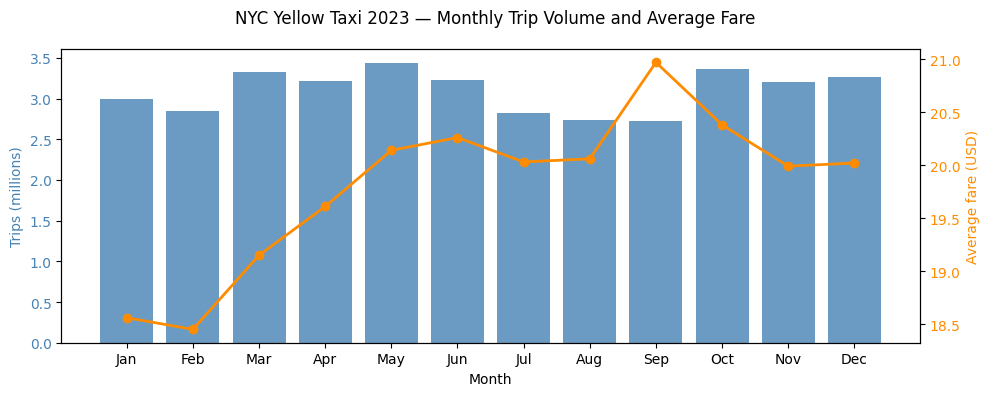

In [16]:
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

con = duckdb.connect("../data/taxi.duckdb")

monthly = con.execute("""
    SELECT
        MONTH(tpep_pickup_datetime)   AS month,
        COUNT(*)                      AS n_trips,
        ROUND(AVG(fare_amount), 2)    AS avg_fare
    FROM trips
    GROUP BY month
    ORDER BY month
""").df()

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax1 = plt.subplots(figsize=(10, 4))

bars = ax1.bar(monthly["month"], monthly["n_trips"] / 1e6,
               color="steelblue", alpha=0.8, label="Trip count (M)")
ax1.set_xlabel("Month")
ax1.set_ylabel("Trips (millions)", color="steelblue")
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_labels)
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(monthly["month"], monthly["avg_fare"], color="darkorange",
         marker="o", linewidth=2, label="Avg fare (USD)")
ax2.set_ylabel("Average fare (USD)", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

fig.suptitle("NYC Yellow Taxi 2023 — Monthly Trip Volume and Average Fare",
             fontsize=12)
fig.tight_layout()
plt.savefig("../outputs/taxi_monthly_trips.png", dpi=150, bbox_inches="tight")
plt.show()